<a href="https://www.kaggle.com/code/adegbaju/hospital-readmission-prediction-combined-dataset?scriptVersionId=323442927" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Hospital Readmission Prediction  Combined Dataset Approach

# Setup & Library Imports

In [1]:
# Data manipulation & analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Handle imbalanced classes
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Ignore warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
%matplotlib inline

##  Load the Datasets

In [2]:
# Adjust paths to match your Kaggle environment
READMISSION_PATH = '/kaggle/input/datasets/mohamedasak/hospital-patient-readmission-dataset/hospital_readmission_dataset.csv'
HEALTHCARE_PATH = '/kaggle/input/datasets/prashantkumaryt/health-care-real-world-data-55k-patients/Healthcare_dataset.csv'

# Load readmission dataset (main task)
df_readm = pd.read_csv(READMISSION_PATH)
print('Readmission dataset shape:', df_readm.shape)

# Load large healthcare dataset (for feature augmentation)
df_health = pd.read_csv(HEALTHCARE_PATH)
print('Healthcare dataset shape:', df_health.shape)

Readmission dataset shape: (8000, 17)
Healthcare dataset shape: (55500, 15)


## Initial Exploration  Readmission Dataset

In [3]:
# First few rows
df_readm.head()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


In [4]:
# Data types and missing values
df_readm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type             8000 non-null   objec

In [5]:
# Summary statistics
df_readm.describe(include='all')

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
count,8000,8000,8000,8000.000000,8000,8000,8000,8000.000000,8000.000000,8000,8000.000000,8000.000000,8000.00000,8000,8000,8000.000000,8000.000000
unique,8000,1092,4,NaN,2,5,11,NaN,NaN,4,NaN,NaN,NaN,4,4,NaN,NaN
top,P00001,2021-04-21,Winter,NaN,Female,South,Diabetes,NaN,NaN,Medical,NaN,NaN,NaN,Private,Home Health,NaN,NaN
freq,1,16,2041,NaN,4184,1993,1470,NaN,NaN,3588,NaN,NaN,NaN,3052,6065,NaN,NaN
mean,NaN,NaN,NaN,57.411625,NaN,NaN,NaN,4.318500,7.789125,NaN,7.475750,3.638125,1.57250,NaN,NaN,0.776937,0.772875
std,NaN,NaN,NaN,16.724388,NaN,NaN,NaN,1.358046,1.930252,NaN,2.287917,1.630415,0.89196,NaN,NaN,0.219885,0.419000
min,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,1.000000,3.000000,NaN,2.000000,0.000000,0.00000,NaN,NaN,0.070000,0.000000
25%,NaN,NaN,NaN,46.000000,NaN,NaN,NaN,3.000000,6.000000,NaN,6.000000,2.000000,1.00000,NaN,NaN,0.630000,1.000000
50%,NaN,NaN,NaN,57.000000,NaN,NaN,NaN,4.000000,8.000000,NaN,8.000000,4.000000,1.00000,NaN,NaN,0.860000,1.000000
75%,NaN,NaN,NaN,69.000000,NaN,NaN,NaN,5.000000,9.000000,NaN,9.000000,4.000000,2.00000,NaN,NaN,0.970000,1.000000


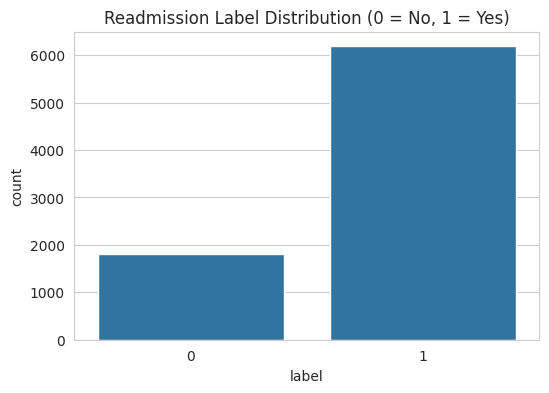

label
1    0.772875
0    0.227125
Name: proportion, dtype: float64


In [6]:
# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df_readm, x='label')
plt.title('Readmission Label Distribution (0 = No, 1 = Yes)')
plt.show()
print(df_readm['label'].value_counts(normalize=True))

## Initial Exploration Healthcare Dataset

In [7]:
df_health.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [8]:
df_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [9]:
# Check for obvious issues
# - Inconsistent name capitalisation
# - Age range
# - Billing amount outliers
print('Age range:', df_health['Age'].min(), '-', df_health['Age'].max())
print('Billing amount range:', df_health['Billing Amount'].min(), '-', df_health['Billing Amount'].max())

Age range: 13 - 89
Billing amount range: -2008.4921398591305 - 52764.276736469175


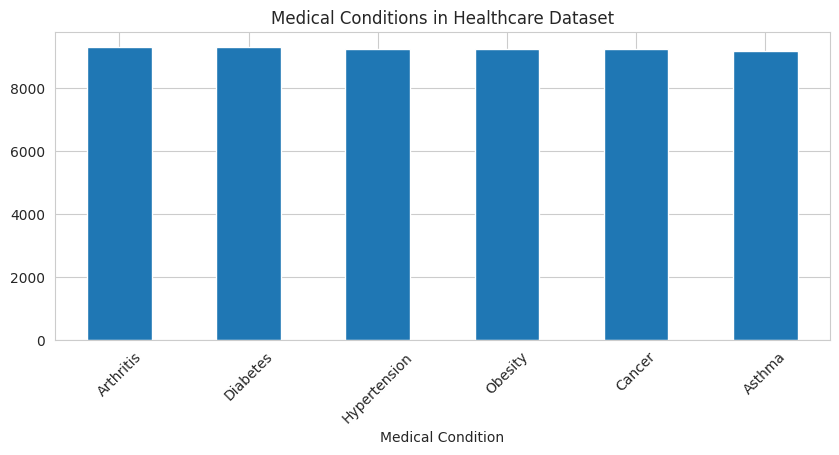

In [10]:
# Distribution of Medical Condition (potential link to readmission 'primary_diagnosis')
plt.figure(figsize=(10,4))
df_health['Medical Condition'].value_counts().plot(kind='bar')
plt.title('Medical Conditions in Healthcare Dataset')
plt.xticks(rotation=45)
plt.show()

#  Feature Engineering Combining the Datasets 

## Harmonise Diagnosis Names

In [11]:
# Clean and standardise diagnosis names in both datasets
def clean_diagnosis(diag):
    diag = diag.strip().lower()
    # Common replacements to align categories
    mapping = {
        'heart disease': 'heart failure',
        'asthma': 'copd',          # both respiratory, unify for simplicity
        'obesity': 'obesity',
        'diabetes': 'diabetes',
        'hypertension': 'hypertension',
        'cancer': 'cancer',
        'stroke': 'stroke',
        'copd': 'copd',
        'pneumonia': 'pneumonia',
        'kidney disease': 'kidney disease',
        'sepsis': 'sepsis',
        'appendicitis': 'appendicitis',
        'fracture': 'fracture',
        'influenza': 'influenza',
        'arthritis': 'arthritis',
        'obesity': 'obesity'       # already covered
    }
    return mapping.get(diag, diag)

df_readm['diag_clean'] = df_readm['primary_diagnosis'].apply(clean_diagnosis)
df_health['diag_clean'] = df_health['Medical Condition'].str.strip().str.lower().apply(clean_diagnosis)

# Check overlap
common_diag = set(df_readm['diag_clean']) & set(df_health['diag_clean'])
print('Diagnoses present in both:', common_diag)

Diagnoses present in both: {'diabetes', 'hypertension', 'copd'}


## Calculate Length of Stay and Clean Billing in Healthcare Data

In [12]:
# Convert date columns
df_health['Date of Admission'] = pd.to_datetime(df_health['Date of Admission'], dayfirst=False)
df_health['Discharge Date'] = pd.to_datetime(df_health['Discharge Date'], dayfirst=False)

# Calculate length of stay (days)
df_health['los'] = (df_health['Discharge Date'] - df_health['Date of Admission']).dt.days

# Remove unrealistic LOS (negative or > 365)
df_health = df_health[(df_health['los'] >= 0) & (df_health['los'] <= 365)]

# Clean billing: replace negatives with NaN and impute later
df_health.loc[df_health['Billing Amount'] < 0, 'Billing Amount'] = np.nan

## Aggregate Features per Diagnosis

In [13]:
diag_stats = df_health.groupby('diag_clean').agg(
    avg_billing = ('Billing Amount', 'mean'),
    median_billing = ('Billing Amount', 'median'),
    avg_los = ('los', 'mean'),
    median_los = ('los', 'median'),
    most_common_admission = ('Admission Type', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'),
    most_common_medication = ('Medication', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'),
    avg_age = ('Age', 'mean'),
    patient_count = ('Name', 'count')
).reset_index()

diag_stats.rename(columns={'diag_clean': 'diag_clean'}, inplace=True)
diag_stats.head()

,diag_clean,avg_billing,median_billing,avg_los,median_los,most_common_admission,most_common_medication,avg_age,patient_count
0,arthritis,25528.123850,25602.585653,15.517404,15.0,Urgent,Aspirin,51.565320,9308
1,cancer,25214.907067,24990.577332,15.495827,15.0,Elective,Lipitor,51.558795,9227
2,copd,25686.666418,25704.988507,15.696570,16.0,Elective,Paracetamol,51.575830,9185
3,diabetes,25694.503197,25659.901058,15.422936,15.0,Urgent,Lipitor,51.554170,9304
4,hypertension,25556.094106,25322.202459,15.458626,15.0,Elective,Ibuprofen,51.741915,9245


In [14]:
# Also aggregate insurance/provider patterns per diagnosis
insurance_diag = df_health.groupby('diag_clean')['Insurance Provider'].value_counts(normalize=True).unstack(fill_value=0)
insurance_diag.columns = ['ins_frac_' + col.replace(' ', '_') for col in insurance_diag.columns]
insurance_diag = insurance_diag.reset_index()

# Merge all diagnostics stats into readmission dataset
df_readm = df_readm.merge(diag_stats, on='diag_clean', how='left')
df_readm = df_readm.merge(insurance_diag, on='diag_clean', how='left')

print('New shape after merging:', df_readm.shape)

New shape after merging: (8000, 31)


# Data Cleaning & Feature Selection 

## Drop Unnecessary Columns

In [15]:
# Drop identifiers and the temporary clean diagnosis column
cols_to_drop = ['patient_id', 'admission_date', 'diag_clean']
df_readm.drop(columns=cols_to_drop, inplace=True)

## Handle Missing Values

In [16]:
# Check missing values
missing = df_readm.isnull().sum()
print(missing[missing > 0])

avg_billing                  4277
median_billing               4277
avg_los                      4277
median_los                   4277
most_common_admission        4277
most_common_medication       4277
avg_age                      4277
patient_count                4277
ins_frac_Aetna               4277
ins_frac_Blue_Cross          4277
ins_frac_Cigna               4277
ins_frac_Medicare            4277
ins_frac_UnitedHealthcare    4277
dtype: int64


## Separate Features and Target

In [17]:
X = df_readm.drop('label', axis=1)
y = df_readm['label']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (8000, 27)
Target shape: (8000,)


# Preprocessing Pipeline

In [18]:
# Identify categorical and numeric columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print('Categorical columns:', cat_cols)
print('Numerical columns:', num_cols)

# Preprocessing for numeric data
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

Categorical columns: ['season', 'gender', 'region', 'primary_diagnosis', 'treatment_type', 'insurance_type', 'discharge_disposition', 'most_common_admission', 'most_common_medication']
Numerical columns: ['age', 'comorbidities_count', 'length_of_stay', 'medications_count', 'followup_visits_last_year', 'prev_readmissions', 'readmission_risk_score', 'avg_billing', 'median_billing', 'avg_los', 'median_los', 'avg_age', 'patient_count', 'ins_frac_Aetna', 'ins_frac_Blue_Cross', 'ins_frac_Cigna', 'ins_frac_Medicare', 'ins_frac_UnitedHealthcare']


# Model Building & Evaluation

## Define Models and Cross‑Validation Setup

In [19]:
# Classifiers to test
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=(len(y)-y.sum())/y.sum(),
              objective='binary:logistic',
              eval_metric='logloss',
              random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

##  Evaluate Without Hyper‑Tuning (Baseline)

In [20]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    # Build pipeline: preprocessor -> SMOTE -> classifier
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name}: ROC-AUC mean = {scores.mean():.4f} (± {scores.std():.4f})')

Logistic Regression: ROC-AUC mean = 0.8334 (± 0.0120)
Random Forest: ROC-AUC mean = 0.8158 (± 0.0183)
XGBoost: ROC-AUC mean = 0.8012 (± 0.0165)


# Hyper‑Parameter Tuning for XGBoost

In [21]:
# Define parameter grid for XGBoost
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

# Build final pipeline
xgb_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(scale_pos_weight=(len(y)-y.sum())/y.sum(),
                                 eval_metric='logloss',
                                 random_state=42))
])

# Set up grid search
grid = GridSearchCV(xgb_pipe, param_grid, cv=cv, scoring='roc_auc',
                    n_jobs=-1, verbose=1)
grid.fit(X, y)

print('Best ROC-AUC:', grid.best_score_)
print('Best parameters:', grid.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best ROC-AUC: 0.8339069770740746
Best parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}


## Hyper‑Parameter Tuning for Logistic Regression

In [22]:
log_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(log_pipe, param_grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X, y)
print('Best Logistic Regression ROC-AUC:', grid_lr.best_score_)

Best Logistic Regression ROC-AUC: 0.8358174484765435


# Final Evaluation on a Hold‑Out Test Set

Test ROC-AUC: 0.8345
Test PR-AUC: 0.9399

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.94      0.55       363
           1       0.97      0.56      0.71      1237

    accuracy                           0.65      1600
   macro avg       0.68      0.75      0.63      1600
weighted avg       0.84      0.65      0.67      1600



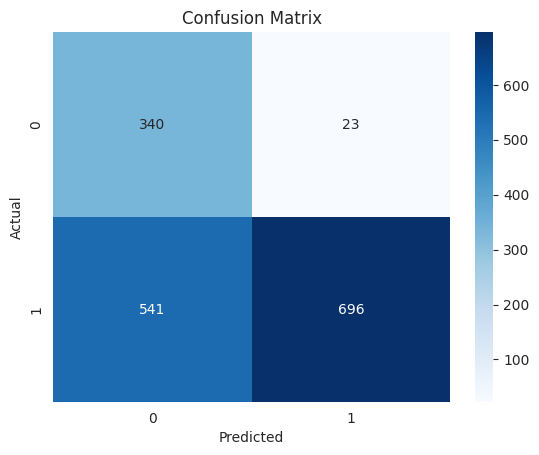

In [23]:
# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Retrain best model on full training data
best_pipe = grid.best_estimator_
best_pipe.fit(X_train, y_train)

# Predict probabilities and class labels
y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred = best_pipe.predict(X_test)

# ROC-AUC
roc = roc_auc_score(y_test, y_proba)
print(f'Test ROC-AUC: {roc:.4f}')

# Precision-Recall AUC
pr_auc = average_precision_score(y_test, y_proba)
print(f'Test PR-AUC: {pr_auc:.4f}')

# Classification report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance 

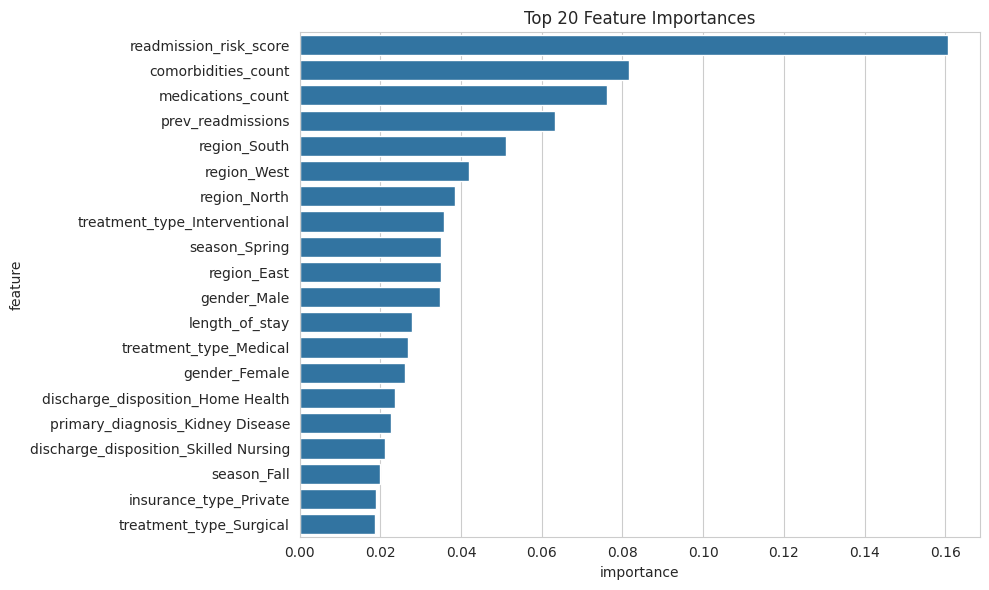

In [24]:
# Extract feature names after preprocessing
# OneHotEncoder creates new columns; we can retrieve them from the pipeline
preprocessor = best_pipe.named_steps['preprocessor']
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_features = cat_encoder.get_feature_names_out(cat_cols)
all_features = np.concatenate([num_cols, cat_features])

# Get importance from XGBoost
importances = best_pipe.named_steps['classifier'].feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({'feature': all_features, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

# Save the model

In [25]:
import joblib

# best_pipe is your tuned pipeline (XGBoost or Logistic Regression)
joblib.dump(best_pipe, 'readmission_pipeline.pkl')
print("Model saved as 'readmission_pipeline.pkl'")

Model saved as 'readmission_pipeline.pkl'
